# BDA 학습자 수료 예측 - 베이스라인

**대회**: 데이콘 x BDA 제 2회 학습자 수료 예측 AI 경진대회  
**목표**: BDA 9기 데이터로 10기 학습자 수료 여부 예측  
**평가**: F1 Score

---

## 📋 목차
1. 라이브러리 임포트
2. 데이터 로드
3. 데이터 확인 (EDA)
4. 시각화
5. 데이터 전처리
6. 특징 추출
7. 모델 학습
8. 예측 및 제출

## 1. 라이브러리 임포트

In [25]:
!pip install pandas numpy scikit-learn seaborn matplotlib xgboost

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Handle font warnings by setting a standard font
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료!")

✅ 라이브러리 임포트 완료!


## 2. 데이터 로드

In [27]:
# 데이터 경로 설정
DATA_PATH = 'C:/Users/dell/bda/open/'

# 데이터 로드
train = pd.read_csv(DATA_PATH + 'train.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print("✅ 데이터 로드 완료!")
print(f"📊 Train 데이터: {train.shape}")
print(f"📊 Test 데이터: {test.shape}")
print(f"📊 Submission: {submission.shape}")

✅ 데이터 로드 완료!
📊 Train 데이터: (748, 46)
📊 Test 데이터: (814, 45)
📊 Submission: (814, 2)


## 3. 데이터 확인 (EDA)

In [28]:
# Train 데이터 정보
print("[Train 데이터 정보]")
print(train.info())

print("\n[Train 데이터 샘플]")
display(train.head())

print("\n[Train 데이터 통계]")
display(train.describe())

[Train 데이터 정보]
<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               748 non-null    str    
 1   generation                       748 non-null    int64  
 2   school1                          748 non-null    int64  
 3   major type                       726 non-null    str    
 4   major1_1                         728 non-null    str    
 5   major1_2                         309 non-null    str    
 6   major_data                       748 non-null    bool   
 7   job                              748 non-null    str    
 8   class1                           748 non-null    int64  
 9   class2                           169 non-null    float64
 10  class3                           14 non-null     float64
 11  class4                           1 non-null      float64
 12  re_registration   

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,...,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
0,TRAIN_000,9,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,...,해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업",NaN,NaN,"Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,TRAIN_001,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",NaN,NaN,머신러닝 / 딥러닝 응용,0
2,TRAIN_002,9,27,단일 전공,예체능,NaN,False,대학생,7,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 적으면 서로 부담스러울 수 있을 것 같지만 너무 많으면 너무 피상적인 ...,Lg전자,"C. 제조업, K. 금융 및 보험업, R. 예술, 스포츠 및 여가관련 서비스업",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0
3,TRAIN_003,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",사회과학,IT(컴퓨터 공학 포함),False,대학생,7,NaN,...,국내 빅테크 IT 계열 (네카라쿠배당토),"온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 강의하면 루즈해질 것 같아서,네이버,"J. 정보통신업, K. 금융 및 보험업",NaN,NaN,머신러닝 / 딥러닝 응용,1
4,TRAIN_004,9,16,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),True,대학생,8,NaN,...,"국내 대기업 IT 계열 (금융, 제조 ...)","온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,다양한 사람들에게 기회가 있으면 좋겠습니다.,네이버,"K. 금융 및 보험업, M. 전문, 과학 및 기술 서비스업, R. 예술, 스포츠 및...",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0



[Train 데이터 통계]


,generation,school1,class1,class2,class3,class4,contest_award,completed_semester,time_input,idea_contest,completed
count,748.0,748.000000,748.000000,169.000000,14.000000,1.0,0.0,720.000000,748.000000,0.0,748.000000
mean,9.0,27.909091,4.970588,6.224852,8.285714,12.0,NaN,65.125028,2.326471,NaN,0.298128
std,0.0,21.401429,3.412975,3.465352,3.172686,NaN,NaN,1068.223643,1.365925,NaN,0.457742
min,9.0,0.000000,1.000000,2.000000,5.000000,12.0,NaN,0.000000,0.000000,NaN,0.000000
25%,9.0,13.000000,2.000000,4.000000,6.000000,12.0,NaN,5.000000,2.000000,NaN,0.000000
50%,9.0,24.000000,4.000000,5.000000,7.000000,12.0,NaN,6.000000,2.000000,NaN,0.000000
75%,9.0,38.000000,7.000000,8.000000,12.000000,12.0,NaN,8.000000,3.000000,NaN,1.000000
max,9.0,91.000000,13.000000,13.000000,13.000000,12.0,NaN,20241.000000,24.000000,NaN,1.000000


In [29]:


# 결측치 확인
print("[결측치 확인]")
print("\nTrain 결측치:")
print(train.isnull().sum())

print("\n[Train 결측치 통계]")
display(train.isnull().describe())

#print("\nTest 결측치:")
#print(test.isnull().sum())

[결측치 확인]

Train 결측치:
ID                                   0
generation                           0
school1                              0
major type                          22
major1_1                            20
major1_2                           439
major_data                           0
job                                  0
class1                               0
class2                             579
class3                             734
class4                             747
re_registration                      0
contest_award                      748
nationality                          1
inflow_route                         0
whyBDA                               0
what_to_gain                         0
hope_for_group                       0
previous_class_3                   602
previous_class_4                   602
previous_class_5                   602
previous_class_6                   602
previous_class_7                   602
previous_class_8                   602
majo

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,...,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
count,748,748,748,748,748,748,748,748,748,748,...,748,748,748,748,748,748,748,748,748,748
unique,1,1,1,2,2,2,1,1,1,2,...,1,1,1,1,1,1,2,1,1,1
top,False,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,True,False,False
freq,748,748,748,726,728,439,748,748,748,579,...,748,748,748,748,748,748,742,748,748,748


In [30]:
# 타겟 변수 확인
if 'completion' in train.columns:
    target_col = 'completion'
elif 'target' in train.columns:
    target_col = 'target'
else:
    target_col = train.columns[-1]

print(f"타겟 컬럼: {target_col}")
print("\n[타겟 변수 분포]")
print(train[target_col].value_counts())
print(f"\n수료율: {train[target_col].mean()*100:.2f}%")

타겟 컬럼: completed

[타겟 변수 분포]
completed
0    525
1    223
Name: count, dtype: int64

수료율: 29.81%


## 4. 데이터 시각화

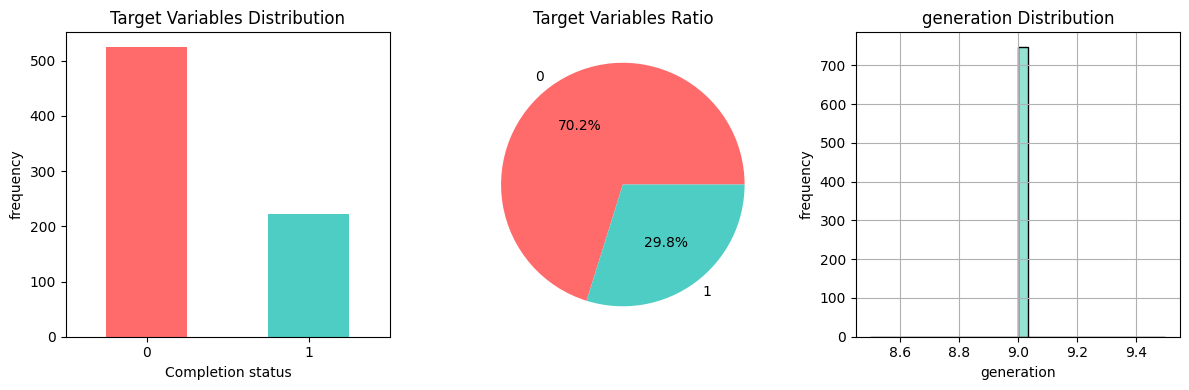

In [31]:
# 타겟 변수 분포 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
train[target_col].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
#plt.title('타겟 변수 분포')
plt.title('Target Variables Distribution')
#plt.xlabel('수료 여부')
plt.xlabel('Completion status')
#plt.ylabel('빈도')
plt.ylabel('frequency')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
train[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
#plt.title('타겟 변수 비율')
plt.title('Target Variables Ratio')
plt.ylabel('')

# 수치형 변수 분포
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

if len(numeric_cols) > 0:
    plt.subplot(1, 3, 3)
    train[numeric_cols[0]].hist(bins=30, color='#95E1D3', edgecolor='black')
    plt.title(f'{numeric_cols[0]} Distribution')
    plt.xlabel(numeric_cols[0])
    plt.ylabel('frequency')

plt.tight_layout()
plt.show()

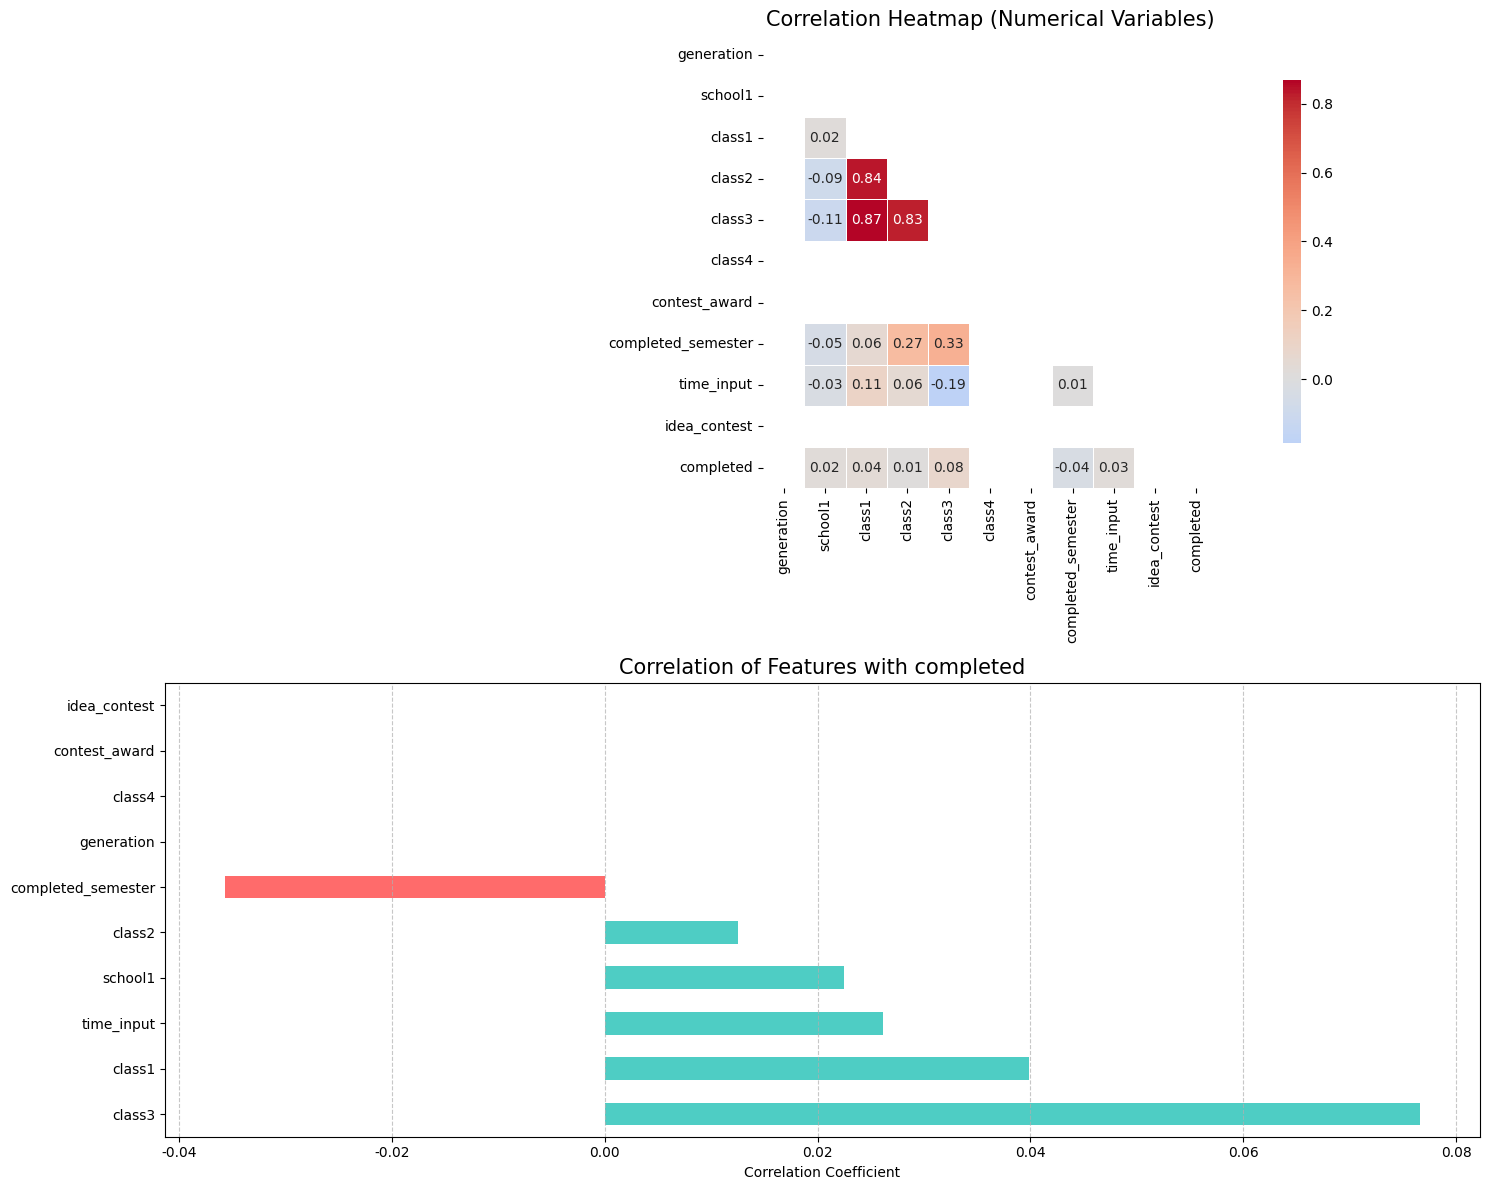

In [32]:
# Correlation Analysis
plt.figure(figsize=(15, 12))

# Calculate correlation
correlation = train[numeric_cols + [target_col]].corr()

# 1. Correlation Heatmap
plt.subplot(2, 1, 1)
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"size": 10})
plt.title('Correlation Heatmap (Numerical Variables)', fontsize=15)

# 2. Correlation with Target (Bar Plot)
plt.subplot(2, 1, 2)
target_corr = correlation[target_col].drop(target_col).sort_values(ascending=False)
colors = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title(f'Correlation of Features with {target_col}', fontsize=15)
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Top 4 features correlated with 'completed': ['class3', 'class1', 'completed_semester', 'time_input']


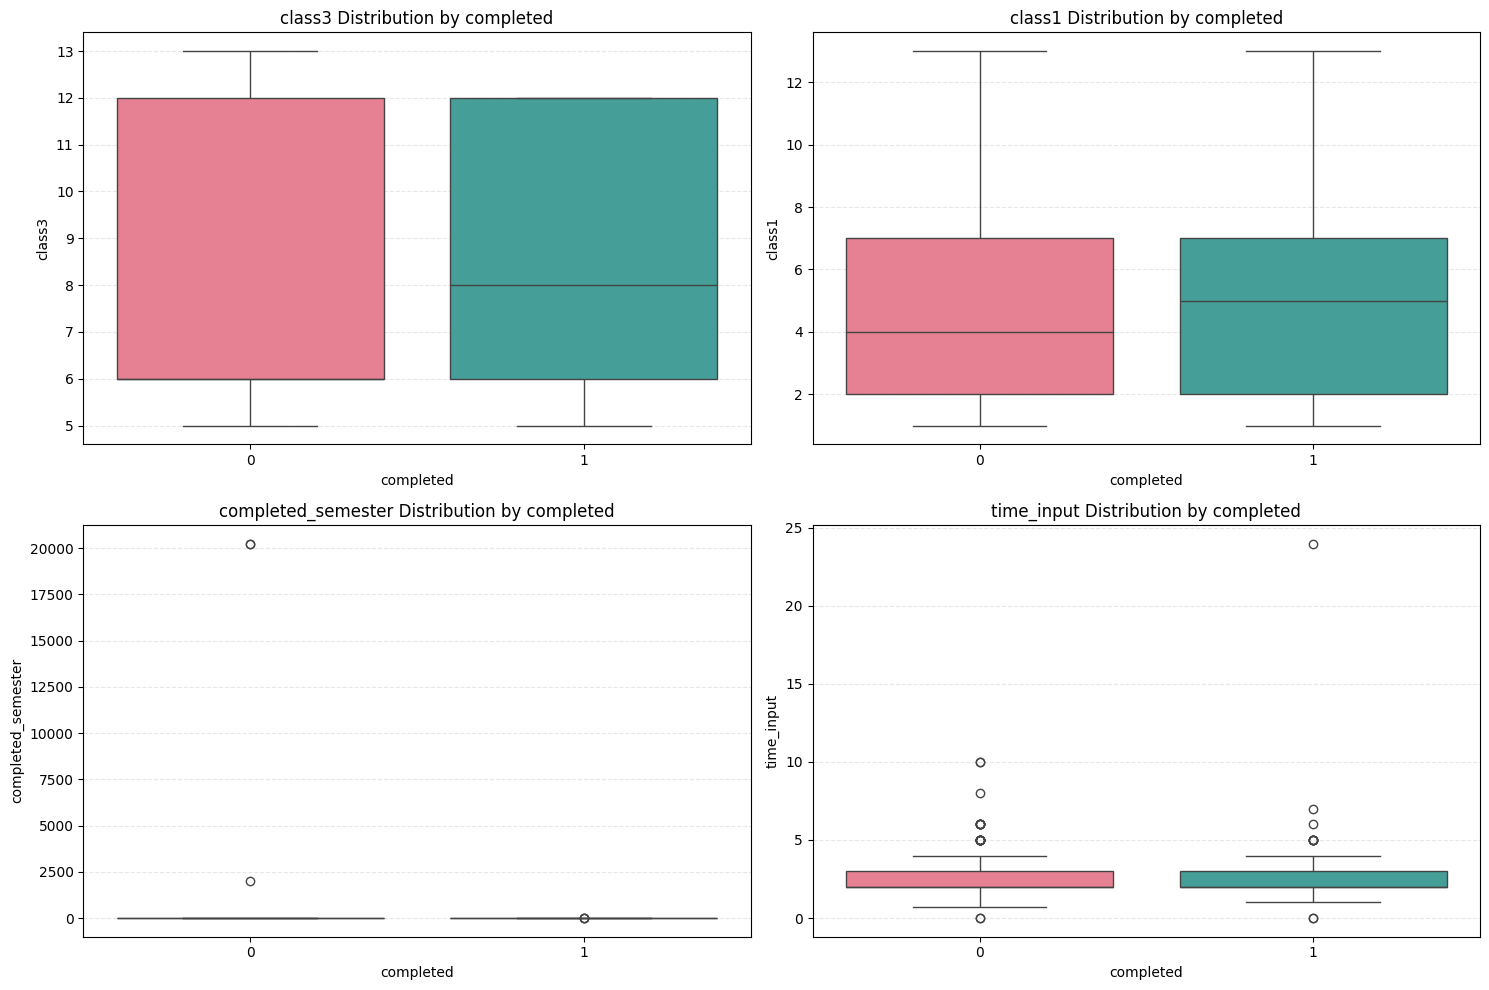

In [33]:
# Analysis of Top Correlated Features
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

print(f"Top 4 features correlated with '{target_col}': {top_features}")

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_features):
    plt.subplot(2, 2, i+1)
    # Using boxplot as it's better for numerical vs binary target
    sns.boxplot(x=target_col, y=col, data=train, palette='husl')
    plt.title(f'{col} Distribution by {target_col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. 데이터 전처리 및 특징 추출

In [34]:
# 5. 데이터 전처리 및 특징 추출 (Preprocessing & Feature Engineering)
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df, is_train=True, train_stats=None):
    df = df.copy()
    
    # 1. ID 컬럼 제거 (대소문자 모두 대응)
    id_cols = ['ID', 'id']
    df = df.drop(columns=[col for col in id_cols if col in df.columns])
    
    # --- 1단계: 결측치 처리 ---
    cols_to_drop = ['contest_award', 'idea_contest']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    
    # 특수 카테고리 
    for col in ['class2', 'class3', 'class4']:
        if col in df.columns:
            df[col] = df[col].fillna(-1)
            
    # 이전 기수 수강 / 대회 경험 / 복수전공 등 문자열 결측치 처리
    string_na_map = {
        'previous_class': '신규학생',
        'contest_participation': '경험없음',
        'major1_2': '단일전공'
    }
    for prefix, fill_val in string_na_map.items():
        cols = [col for col in df.columns if col.startswith(prefix)]
        for col in cols:
            df[col] = df[col].fillna(fill_val)
        
    # 3. 일반적 대체 (중앙값/최빈값)
    if is_train:
        stats = {}
        stats['comp_sem_median'] = df['completed_semester'].median() if 'completed_semester' in df.columns else 0
        stats['modes'] = {col: df[col].mode()[0] for col in ['major type', 'major1_1', 'major_field', 'nationality'] if col in df.columns}
        stats['encoders'] = {}
    else:
        stats = train_stats
        
    if 'completed_semester' in df.columns:
        df['completed_semester'] = df['completed_semester'].fillna(stats['comp_sem_median'])
    for col, mode_val in stats['modes'].items():
        if col in df.columns:
            df[col] = df[col].fillna(mode_val)
        
    # --- 2단계: 특징 추출 ---
    if 'class1' in df.columns:
        df['total_classes'] = df['class1'].fillna(0) + \
                             df.get('class2', 0).replace(-1, 0) + \
                             df.get('class3', 0).replace(-1, 0) + \
                             df.get('class4', 0).replace(-1, 0)
    
    if 'completed_semester' in df.columns:
        df['completed_semester'] = df['completed_semester'].apply(lambda x: x if x <= 12 else 0)
    
    if 'onedayclass_topic' in df.columns:
        df['topic_count'] = df['onedayclass_topic'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
    
    if 'time_input' in df.columns:
        df['has_time_input'] = df['time_input'].apply(lambda x: 1 if x > 0 else 0)
        
    # --- 3단계: 범주형 인코딩 (Label Encoding) ---
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    for col in cat_cols:
        if is_train:
            le = LabelEncoder()
            # 결측값이 있을 수 있으므로 문자열 변환 후 학습
            df[col] = df[col].astype(str)
            le.fit(df[col])
            stats['encoders'][col] = le
        else:
            le = stats['encoders'].get(col)
            if le:
                df[col] = df[col].astype(str)
                # 새로운 카테고리가 있을 경우에 대비해 처리 (또는 train 시 combined fit 사용 권장)
                # 여기서는 train stats의 encoder를 사용
                # le.classes_에 없는 값은 가장 빈번한 값으로 처리하거나 별도 처리 필요
                df[col] = df[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        
        if le:
            df[col] = le.transform(df[col])
            
    if is_train:
        return df, stats
    return df

# 적용
X_train, train_stats = preprocess_data(train.drop(columns=[target_col]), is_train=True)
X_test = preprocess_data(test, is_train=False, train_stats=train_stats)
y_train = train[target_col]

print("✅ 전처리, 특징 추출 및 인코딩 완료!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
X_train.head()

✅ 전처리, 특징 추출 및 인코딩 완료!
X_train shape: (748, 45), y_train shape: (748,)


,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,class3,...,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,onedayclass_topic,total_classes,topic_count,has_time_input
0,9,22,2,2,10,False,0,1,4.0,-1.0,...,1,2,132,88,135,1,9,5.0,5,1
1,9,1,2,10,0,True,0,8,-1.0,-1.0,...,0,5,191,329,98,1,34,8.0,1,1
2,9,27,0,7,5,False,0,7,-1.0,-1.0,...,0,5,370,41,21,1,36,7.0,3,1
3,9,1,2,6,0,False,0,7,-1.0,-1.0,...,1,5,73,114,66,1,34,7.0,1,1
4,9,16,2,0,0,True,0,8,-1.0,-1.0,...,1,5,133,114,118,1,36,8.0,3,1


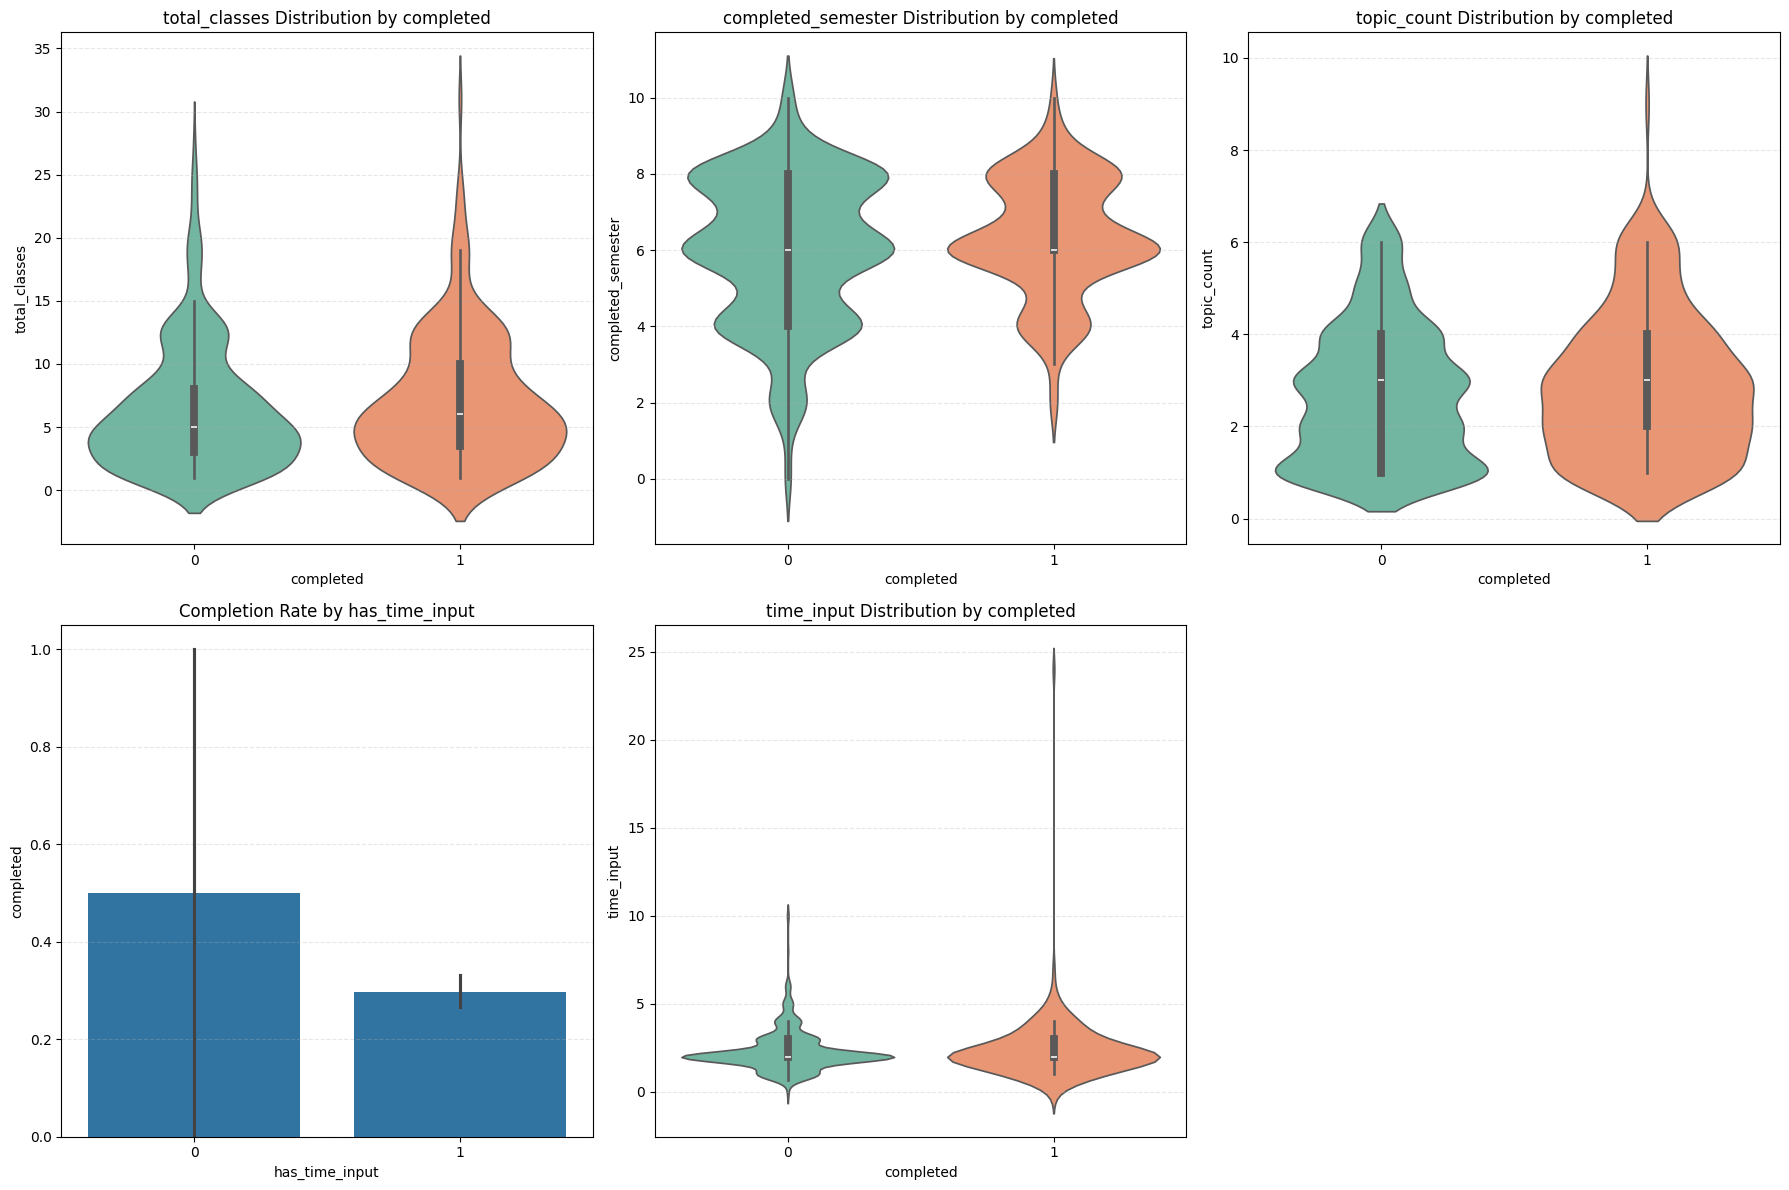

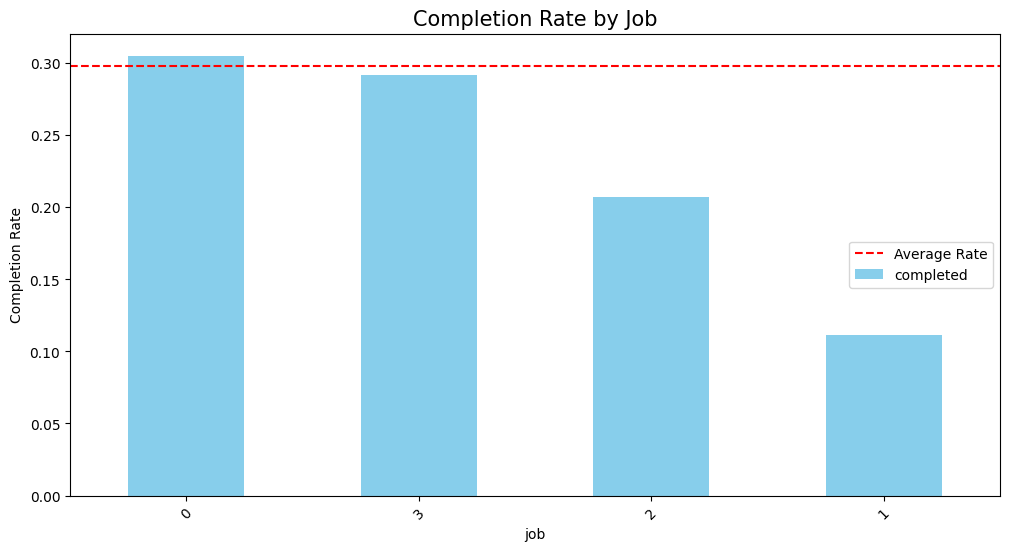

In [35]:
# 시각화용 데이터프레임 생성 (X_train + target)
train_eng = X_train.copy()
train_eng[target_col] = y_train.values

# 신규 특징과 타겟 변수의 상관관계 시각화
new_features = ['total_classes', 'completed_semester', 'topic_count', 'has_time_input', 'time_input']
# 존재하는 컬럼만 필터링
new_features = [col for col in new_features if col in train_eng.columns]

plt.figure(figsize=(18, 12))
for i, col in enumerate(new_features):
    plt.subplot(2, 3, i+1)
    if col == 'has_time_input':
        sns.barplot(x=col, y=target_col, data=train_eng)
        plt.title(f'Completion Rate by {col}')
    else:
        sns.violinplot(x=target_col, y=col, data=train_eng, palette='Set2')
        plt.title(f'{col} Distribution by {target_col}')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 범주형 변수 수료율 분석 (Job) - job 컬럼이 있는 경우만
if 'job' in train_eng.columns:
    plt.figure(figsize=(12, 6))
    job_completion = train_eng.groupby('job')[target_col].mean().sort_values(ascending=False)
    job_completion.plot(kind='bar', color='skyblue')
    plt.title('Completion Rate by Job', fontsize=15)
    plt.ylabel('Completion Rate')
    plt.xticks(rotation=45)
    plt.axhline(y=train_eng[target_col].mean(), color='r', linestyle='--', label='Average Rate')
    plt.legend()
    plt.show()
else:
    print("⚠️ 'job' 컬럼이 없어 Job별 수료율 분석을 건너뜁니다.")

In [36]:
# 트리 기반 모델(RF, GB)은 스케일링 불필요 - 바로 사용
# 스케일링이 필요한 모델(SVM, KNN, NN 등) 사용 시에만 StandardScaler 적용

X_train_scaled = X_train.values  # numpy array로 변환
X_test_scaled = X_test.values

print(f"✅ 데이터 준비 완료!")
print(f"   X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

✅ 데이터 준비 완료!
   X_train: (748, 45), X_test: (814, 45)


## 7. 모델 학습

In [37]:
# Train/Validation 분할
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

print(f"📊 Train: {X_tr.shape}, Validation: {X_val.shape}")

📊 Train: (598, 45), Validation: (150, 45)


In [49]:
# XGBoost 학습
print("[XGBoost 학습]")
xgb_model = xgb.XGBClassifier(
    n_estimators=500,        # 트리의 개수를 늘리고 (early_stopping과 함께 사용 권장)
    max_depth=6,             # 10은 다소 깊을 수 있어 6~8 정도로 조정 권장
    learning_rate=0.05,      # n_estimators를 늘린 만큼 학습률은 낮춤
    
    # --- 추가된 핵심 파라미터 ---
    min_child_weight=1,      # 값이 클수록 트리 분할을 자제 (과적합 방지)
    subsample=0.8,           # 데이터 샘플링 비율 (80%만 무작위 사용)
    colsample_bytree=0.8,    # 피처 샘플링 비율 (80% 피처만 무작위 사용)
    gamma=0.1,               # 트리 분할을 위한 최소 손실 감소 값
    reg_lambda=1.0,          # L2 Regularization (가중치 규제)
    reg_alpha=0,             # L1 Regularization
    
    # --- Early Stopping 설정 (모델 초기화 시 지정) ---
    early_stopping_rounds=50, # 50번 동안 성능 개선 없으면 멈춤
    # --------------------------
    
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 검증 데이터셋을 포함하여 학습
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)], # 검증 데이터 기준
    verbose=False
)

# 검증
y_val_pred_xgb = xgb_model.predict(X_val)
f1_xgb = f1_score(y_val, y_val_pred_xgb, average='weighted')
print(f"✅ XGBoost F1 Score: {f1_xgb:.4f}")

[XGBoost 학습]
✅ XGBoost F1 Score: 0.6008


In [50]:
# Gradient Boosting 학습
print("[Gradient Boosting 학습]")
gb_model = GradientBoostingClassifier(
    n_estimators=200,         # 트리 개수를 약간 늘림
    learning_rate=0.05,       # 학습률을 낮춰 더 세밀하게 학습 (n_estimators와 트레이드오프)
    max_depth=5,              # 기본 GB는 트리가 깊어지면 과적합에 매우 취약함 (5~8 권장)
    
    # --- 추가된 핵심 파라미터 ---
    min_samples_split=20,     # 노드를 분할하기 위한 최소 샘플 수 (과적합 방지)
    min_samples_leaf=5,       # 리프 노드가 되기 위한 최소 샘플 수
    subsample=0.8,            # Stochastic Gradient Boosting: 데이터 일부만 사용하여 일반화 성능 향상
    max_features='sqrt',      # 각 분할에서 사용할 피처의 개수 제한 (속도 향상 및 과적합 방지)
    # --------------------------
    
    validation_fraction=0.1,  # 내부적으로 10%를 검증에 사용 (n_iter_no_change와 함께 사용)
    n_iter_no_change=10,      # 10번 동안 개선 없으면 조기 종료
    random_state=42
)

gb_model.fit(X_tr, y_tr)

# 검증
y_val_pred_gb = gb_model.predict(X_val)
f1_gb = f1_score(y_val, y_val_pred_gb, average='weighted')
print(f"✅ Gradient Boosting F1 Score: {f1_gb:.4f}")

[Gradient Boosting 학습]
✅ Gradient Boosting F1 Score: 0.5918


In [51]:
# 최고 성능 모델 선택
if f1_xgb > f1_gb:
    best_model = xgb_model
    best_model_name = "XGBoost"
    best_f1 = f1_xgb
else:
    best_model = gb_model
    best_model_name = "Gradient Boosting"
    best_f1 = f1_gb

print(f"🏆 최고 성능 모델: {best_model_name} (F1: {best_f1:.4f})")

# 분류 리포트
print("\n[분류 리포트]")
print(classification_report(y_val, best_model.predict(X_val)))

🏆 최고 성능 모델: XGBoost (F1: 0.6008)

[분류 리포트]
              precision    recall  f1-score   support

           0       0.70      0.95      0.81       105
           1       0.38      0.07      0.11        45

    accuracy                           0.69       150
   macro avg       0.54      0.51      0.46       150
weighted avg       0.61      0.69      0.60       150



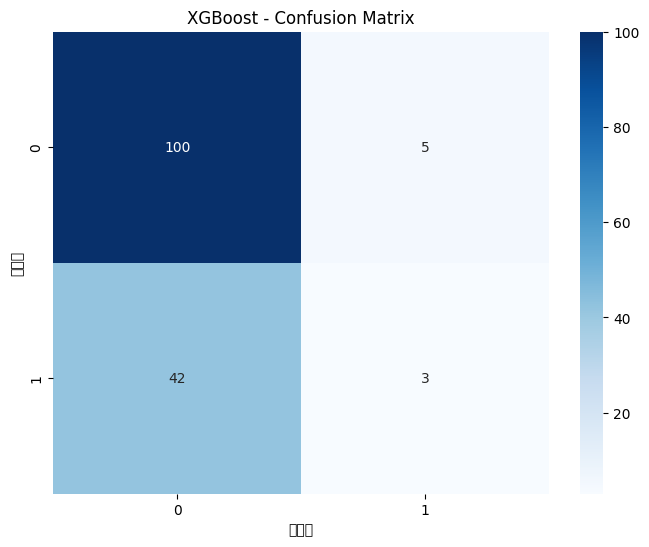

In [52]:
# Confusion Matrix
cm = confusion_matrix(y_val, best_model.predict(X_val))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_model_name} - Confusion Matrix')
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.show()

[Top 10 중요 특징]


,feature,importance
17,previous_class_3,0.158135
21,previous_class_7,0.033845
25,completed_semester,0.029870
22,previous_class_8,0.029751
35,incumbents_lecture_type,0.028570
29,certificate_acquisition,0.028295
6,job,0.027638
14,whyBDA,0.027381
2,major type,0.026606
4,major1_2,0.024256


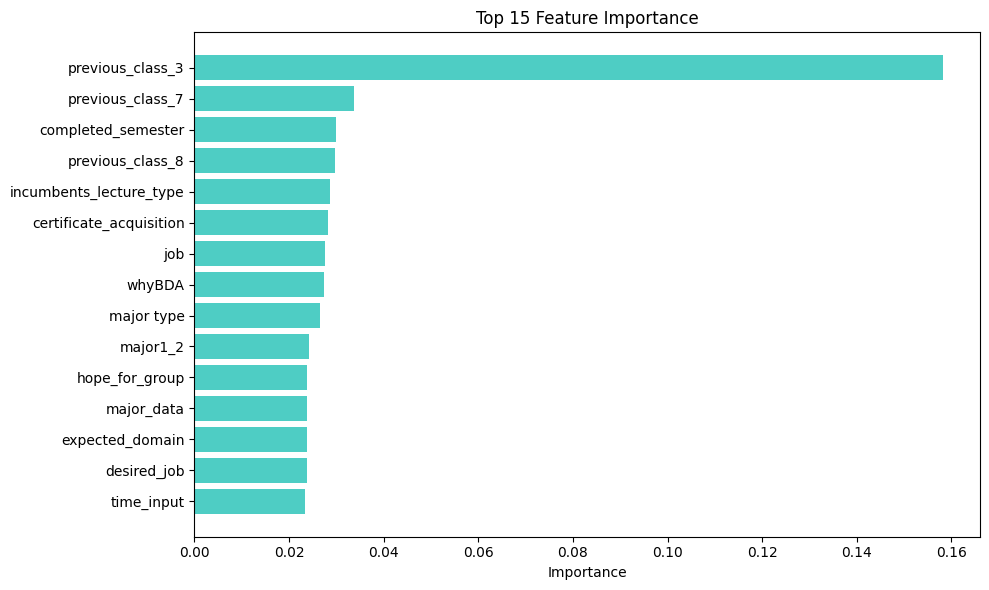

In [53]:
# 특징 중요도
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("[Top 10 중요 특징]")
display(feature_importance.head(10))

# 시각화
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='#4ECDC4')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. 예측 및 제출

In [43]:
# 전체 Train 데이터로 재학습
print("전체 Train 데이터로 모델 재학습 중...")
best_model.fit(X_train_scaled, y_train)

# 테스트 데이터 예측
y_test_pred = best_model.predict(X_test_scaled)

print(f"✅ 예측 완료!")
print(f"📊 예측 분포:")
print(pd.Series(y_test_pred).value_counts())

전체 Train 데이터로 모델 재학습 중...
✅ 예측 완료!
📊 예측 분포:
0    696
1    118
Name: count, dtype: int64


In [44]:
# 제출 파일 생성
submission[target_col] = y_test_pred

# 출력 디렉토리 설정
import os
OUTPUT_PATH = "output/"

# 디렉토리가 없으면 생성
os.makedirs(OUTPUT_PATH, exist_ok=True)

# 기존 submission 파일 개수 확인하여 자동으로 번호 부여
counter = 1
while True:
    submission_path = OUTPUT_PATH + f'submission{counter}.csv'
    if not os.path.exists(submission_path):
        break
    counter += 1

# 저장
submission.to_csv(submission_path, index=False)

print(f"✅ 제출 파일 저장 완료: {submission_path}")
print("\n[제출 파일 샘플]")
display(submission.head(10))

print("\n" + "="*60)
print("🎉 모든 작업 완료!")
print("="*60)
print(f"📊 최종 모델: {best_model_name}")
print(f"📊 검증 F1 Score: {best_f1:.4f}")
print(f"📊 제출 파일: {submission_path}")

✅ 제출 파일 저장 완료: output/submission1.csv

[제출 파일 샘플]


,ID,completed
0,TEST_000,0
1,TEST_001,1
2,TEST_002,0
3,TEST_003,0
4,TEST_004,0
5,TEST_005,1
6,TEST_006,0
7,TEST_007,0
8,TEST_008,0
9,TEST_009,0



🎉 모든 작업 완료!
📊 최종 모델: XGBoost
📊 검증 F1 Score: 0.6385
📊 제출 파일: output/submission1.csv
